<a href="https://colab.research.google.com/github/quantumguy-TR/QML-Practices/blob/main/BBM92_QKD_Egitim.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BBM92 Kuantum Anahtar Dağıtım Protokolü
## Uygulamalı Eğitim Dokümanı (Google Colab)

**BBM92**, 1992’de Charles H. Bennett, Gilles Brassard ve N. David Mermin tarafından önerilen **dolaşıklık tabanlı** bir kuantum anahtar dağıtım (QKD) protokolüdür.  
BB84’ün dolaşıklık versiyonu olarak düşünülebilir. Güvenlik ispatı Bell eşitsizliğine dayanmaz; BB84 ile eşdeğer güvenlik sağlar.

### Bu notebook’ta neler var?
1. Teorik açıklama
2. Adım adım Python simülasyonu
3. İdeal / gürültülü / saldırı senaryoları
4. Görselleştirme
5. Deneyler ve performans analizi

> **Not:** Bu bir **klasik simülasyondur**. Gerçek kuantum donanımı (entangled photon source, single-photon detectors) kullanılmaz; dolaşıklık korelasyonları istatistiksel olarak taklit edilir.


## 1. BBM92 Protokolünün Adımları

| Adım | Açıklama |
|------|----------|
| 1. Dolaşık çift üretimi | Kaynak Bell durumu üretir (ör. $\|\Phi^+\rangle = \frac{1}{\sqrt{2}}(\|00\rangle + \|11\rangle)$) ve bir fotonu Alice’e, diğerini Bob’a gönderir. |
| 2. Baz seçimi | Alice ve Bob bağımsız olarak rastgele **Z** (dik / H-V) veya **X** (çapraz / ±45°) bazını seçer. |
| 3. Ölçüm | Her biri kendi fotonunu seçtiği bazda ölçer ve sonucu (0 veya 1) kaydeder. |
| 4. Sifting | Klasik kanal üzerinden **sadece baz seçimlerini** paylaşırlar. Aynı bazda ölçülen bitler tutulur, diğerleri atılır. |
| 5. QBER tahmini | Sifted key’in bir kısmı açıkça karşılaştırılarak Quantum Bit Error Rate hesaplanır. |
| 6. Hata düzeltme + Privacy Amplification | Hatalar düzeltilir, Eve’in bilgisini azaltmak için anahtar kısaltılır → **güvenli anahtar**. |

### Neden güvenli?
Aynı bazda ölçüm yapıldığında dolaşıklık sayesinde sonuçlar mükemmel korelasyon (veya anti-korelasyon) gösterir. Eve kanalı dinlerse bu korelasyonu bozar ve QBER yükselir. QBER belli bir eşiği (yaklaşık %11) aşarsa protokol iptal edilir.


In [ ]:
# Gerekli kütüphaneler
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import random

# Tekrarlanabilirlik için seed
np.random.seed(42)
random.seed(42)

print("Kütüphaneler yüklendi.")
print(f"NumPy sürümü: {np.__version__}")


Kütüphaneler yüklendi.
NumPy sürümü: 2.0.2


## 2. BBM92 Simülatör Sınıfı

Aşağıdaki sınıf protokolün tüm adımlarını simüle eder:
- Dolaşık çift üretimi (korelasyon / anti-korelasyon)
- Rastgele baz seçimi
- Gürültü / Eve etkisi ekleme
- Sifting
- QBER tahmini
- Basit anahtar üretimi


In [ ]:
class BBM92Simulator:
    def __init__(self, n_pairs=1000, noise=0.0, bell_state='phi_plus'):
        """
        Parametreler
        ------------
        n_pairs : int
            Üretilecek dolaşık foton çifti sayısı
        noise : float (0.0 - 0.5)
            Kanal gürültüsü veya Eve etkisi. Her bit bu olasılıkla ters çevrilir.
        bell_state : str
            'phi_plus'  → korelasyon  (Alice = Bob)
            'psi_minus' → anti-korelasyon (Alice = 1 - Bob)
        """
        self.n_pairs = n_pairs
        self.noise = noise
        self.bell_state = bell_state
        self.bases = ['Z', 'X']  # Z = dik (H/V), X = çapraz (+/-)

    def generate_entangled_outcomes(self):
        """İdeal dolaşıklık + gürültü simülasyonu."""
        # Alice ve Bob bağımsız rastgele baz seçer
        alice_bases = np.random.choice(self.bases, self.n_pairs)
        bob_bases   = np.random.choice(self.bases, self.n_pairs)

        # Alice'in ölçüm sonuçları tamamen rastgele (kuantum rastgeleliği)
        alice_bits = np.random.randint(0, 2, self.n_pairs)

        # Bob'un sonuçları dolaşıklığa göre belirlenir
        bob_bits = alice_bits.copy()

        if self.bell_state == 'psi_minus':
            # Anti-korelasyon
            bob_bits = 1 - bob_bits

        # Farklı bazda ölçüm yapıldıysa korelasyon kaybolur → rastgele sonuç
        different_basis = (alice_bases != bob_bases)
        bob_bits[different_basis] = np.random.randint(0, 2, np.sum(different_basis))

        # Gürültü / Eve etkisi: bazı bitleri ters çevir
        if self.noise > 0:
            flip_mask = np.random.random(self.n_pairs) < self.noise
            bob_bits[flip_mask] = 1 - bob_bits[flip_mask]

        return alice_bases, bob_bases, alice_bits, bob_bits

    def sift(self, alice_bases, bob_bases, alice_bits, bob_bits):
        """Sifting: Sadece aynı bazda ölçülen bitleri tut."""
        match = (alice_bases == bob_bases)
        sifted_alice = alice_bits[match]
        sifted_bob   = bob_bits[match]
        return sifted_alice, sifted_bob, match

    def estimate_qber(self, sifted_alice, sifted_bob, sample_ratio=0.2):
        """
        QBER tahmini: Sifted key'in bir kısmını açıkça karşılaştır.
        Kalan kısım anahtar adayı olur.
        """
        n = len(sifted_alice)
        sample_size = max(1, int(n * sample_ratio)) if n > 0 else 0
        if sample_size == 0:
            return 0.0, np.array([]), np.array([])

        idx = np.random.choice(n, sample_size, replace=False)
        sample_a = sifted_alice[idx]
        sample_b = sifted_bob[idx]

        errors = np.sum(sample_a != sample_b)
        qber = errors / sample_size

        # Örneklenen bitler atılır, kalanlar anahtar için kullanılır
        remaining_mask = np.ones(n, dtype=bool)
        remaining_mask[idx] = False
        key_a = sifted_alice[remaining_mask]
        key_b = sifted_bob[remaining_mask]

        return qber, key_a, key_b

    def run(self, sample_ratio=0.2, qber_threshold=0.11, verbose=True):
        """Tam BBM92 protokolünü çalıştırır."""
        if verbose:
            print(f"▶ {self.n_pairs} dolaşık çift üretiliyor (noise={self.noise}, state={self.bell_state})...")

        a_bases, b_bases, a_bits, b_bits = self.generate_entangled_outcomes()

        if verbose:
            print("▶ Sifting yapılıyor...")
        sifted_a, sifted_b, match = self.sift(a_bases, b_bases, a_bits, b_bits)
        sift_rate = np.mean(match)

        if verbose:
            print(f"   Sift oranı: %{sift_rate*100:.1f}  →  {len(sifted_a)} bit kaldı")

        if verbose:
            print("▶ QBER tahmin ediliyor...")
        qber, key_a, key_b = self.estimate_qber(sifted_a, sifted_b, sample_ratio)

        if verbose:
            print(f"   Tahmini QBER: %{qber*100:.2f}")

        if qber > qber_threshold:
            if verbose:
                print(f"❌ QBER eşiği aşıldı (%{qber_threshold*100:.0f}). Protokol iptal edildi!")
            return None

        remaining_errors = np.sum(key_a != key_b)
        if verbose:
            print(f"   Kalan anahtar adayı: {len(key_a)} bit")
            print(f"   (Hata düzeltme öncesi uyumsuz bit sayısı: {remaining_errors})")

        # Çok kaba privacy amplification tahmini
        # Gerçekte: 1 - h(QBER) - leak  formülü kullanılır
        final_key_length = max(0, int(len(key_a) * (1 - 2.2 * qber - 0.05)))
        final_key = key_a[:final_key_length]

        if verbose:
            print(f"✅ Yaklaşık güvenli anahtar uzunluğu: {len(final_key)} bit")

        return {
            'sifted_length': len(sifted_a),
            'qber': qber,
            'final_key': final_key,
            'final_key_length': len(final_key),
            'alice_bases': a_bases,
            'bob_bases': b_bases,
            'sift_rate': sift_rate
        }

print("BBM92Simulator sınıfı tanımlandı.")


BBM92Simulator sınıfı tanımlandı.


## 3. Protokolü Farklı Senaryolarda Çalıştırma

Üç farklı durumu inceleyelim:
1. **İdeal** (noise = 0) → neredeyse sıfır hata
2. **Hafif gürültü** (noise = 0.05) → gerçekçi kanal
3. **Yüksek gürültü / saldırı** (noise = 0.15) → protokol muhtemelen iptal olur


In [ ]:
print("=" * 65)
print("1. İDEAL DURUM (noise = 0.0)")
print("=" * 65)
sim_ideal = BBM92Simulator(n_pairs=5000, noise=0.0, bell_state='phi_plus')
result_ideal = sim_ideal.run()

print("\n" + "=" * 65)
print("2. GÜRÜLTÜLÜ KANAL (noise = 0.05)")
print("=" * 65)
sim_noisy = BBM92Simulator(n_pairs=5000, noise=0.05, bell_state='phi_plus')
result_noisy = sim_noisy.run()

print("\n" + "=" * 65)
print("3. YÜKSEK GÜRÜLTÜ / EVE SALDIRISI (noise = 0.15)")
print("=" * 65)
sim_attack = BBM92Simulator(n_pairs=5000, noise=0.15, bell_state='phi_plus')
result_attack = sim_attack.run()


1. İDEAL DURUM (noise = 0.0)
▶ 5000 dolaşık çift üretiliyor (noise=0.0, state=phi_plus)...
▶ Sifting yapılıyor...
   Sift oranı: %47.7  →  2385 bit kaldı
▶ QBER tahmin ediliyor...
   Tahmini QBER: %0.00
   Kalan anahtar adayı: 1908 bit
   (Hata düzeltme öncesi uyumsuz bit sayısı: 0)
✅ Yaklaşık güvenli anahtar uzunluğu: 1812 bit

2. GÜRÜLTÜLÜ KANAL (noise = 0.05)
▶ 5000 dolaşık çift üretiliyor (noise=0.05, state=phi_plus)...
▶ Sifting yapılıyor...
   Sift oranı: %49.4  →  2471 bit kaldı
▶ QBER tahmin ediliyor...
   Tahmini QBER: %5.87
   Kalan anahtar adayı: 1977 bit
   (Hata düzeltme öncesi uyumsuz bit sayısı: 90)
✅ Yaklaşık güvenli anahtar uzunluğu: 1622 bit

3. YÜKSEK GÜRÜLTÜ / EVE SALDIRISI (noise = 0.15)
▶ 5000 dolaşık çift üretiliyor (noise=0.15, state=phi_plus)...
▶ Sifting yapılıyor...
   Sift oranı: %50.4  →  2521 bit kaldı
▶ QBER tahmin ediliyor...
   Tahmini QBER: %15.48
❌ QBER eşiği aşıldı (%11). Protokol iptal edildi!


## 4. Görselleştirme

Aşağıdaki grafiklerde:
- Alice ve Bob’un baz seçimleri
- Sifting sonrası kalan / atılan bit oranları
- Sifted key içindeki korelasyon (QBER göstergesi)
görülür.


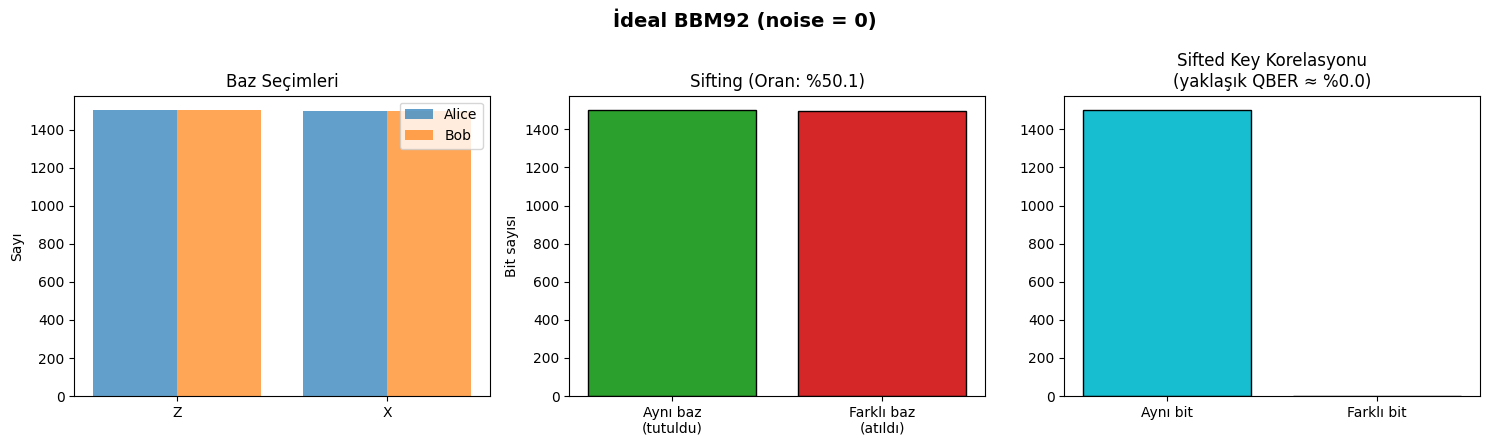

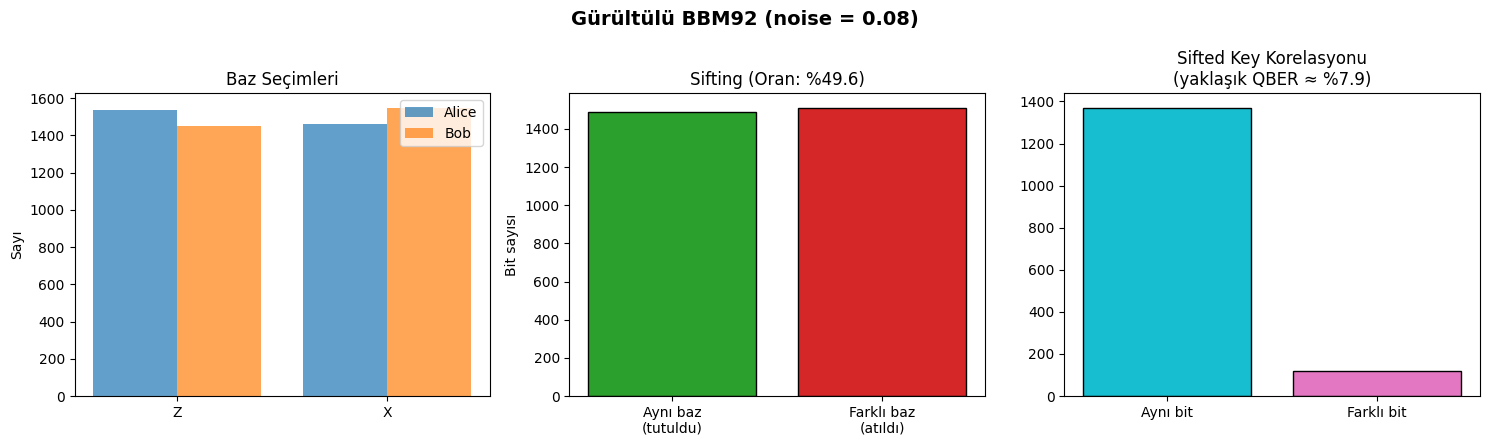

In [ ]:
def visualize_bbm92(sim, title="BBM92 Simülasyonu"):
    a_bases, b_bases, a_bits, b_bits = sim.generate_entangled_outcomes()
    sifted_a, sifted_b, match = sim.sift(a_bases, b_bases, a_bits, b_bits)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

    # 1. Baz seçimleri
    axes[0].hist([list(a_bases), list(b_bases)],
                 label=['Alice', 'Bob'], bins=[-0.5, 0.5, 1.5],
                 alpha=0.7, color=['#1f77b4', '#ff7f0e'])
    axes[0].set_title("Baz Seçimleri", fontsize=12)
    axes[0].set_xticks([0, 1])
    axes[0].set_xticklabels(['Z', 'X'])
    axes[0].legend()
    axes[0].set_ylabel("Sayı")

    # 2. Sift oranı
    axes[1].bar(['Aynı baz\n(tutuldu)', 'Farklı baz\n(atıldı)'],
                [np.sum(match), np.sum(~match)],
                color=['#2ca02c', '#d62728'], edgecolor='black')
    axes[1].set_title(f"Sifting (Oran: %{np.mean(match)*100:.1f})", fontsize=12)
    axes[1].set_ylabel("Bit sayısı")

    # 3. Korelasyon
    if len(sifted_a) > 0:
        same = (sifted_a == sifted_b)
        axes[2].bar(['Aynı bit', 'Farklı bit'],
                    [np.sum(same), np.sum(~same)],
                    color=['#17becf', '#e377c2'], edgecolor='black')
        qber_approx = np.mean(~same) * 100
        axes[2].set_title(f"Sifted Key Korelasyonu\n(yaklaşık QBER ≈ %{qber_approx:.1f})", fontsize=12)
    else:
        axes[2].text(0.5, 0.5, "Yeterli veri yok", ha='center', va='center')
        axes[2].set_title("Sifted Key Korelasyonu")

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# İdeal durum
visualize_bbm92(BBM92Simulator(n_pairs=3000, noise=0.0),
                "İdeal BBM92 (noise = 0)")

# Gürültülü durum
visualize_bbm92(BBM92Simulator(n_pairs=3000, noise=0.08),
                "Gürültülü BBM92 (noise = 0.08)")


## 5. Deneyler ve Performans Analizi

Aşağıdaki hücrede farklı çift sayıları için performans özeti üretilir.  
`noise` değerini değiştirerek kendiniz de deneyebilirsiniz.


In [ ]:
def performance_summary(n_pairs_list=[500, 1000, 2000, 5000, 10000],
                        noise=0.03, sample_ratio=0.15):
    print(f"Performans Özeti  |  noise = {noise}  |  sample_ratio = {sample_ratio}")
    print("-" * 70)
    print(f"{'Çift':>8} | {'Sifted':>8} | {'QBER %':>8} | {'Final Key':>10} | {'Durum':>10}")
    print("-" * 70)

    results = []
    for n in n_pairs_list:
        sim = BBM92Simulator(n_pairs=n, noise=noise)
        res = sim.run(sample_ratio=sample_ratio, verbose=False)
        if res is None:
            print(f"{n:8d} | {'---':>8} | {'---':>8} | {'---':>10} | {'İPTAL':>10}")
        else:
            print(f"{n:8d} | {res['sifted_length']:8d} | {res['qber']*100:8.2f} | "
                  f"{res['final_key_length']:10d} | {'OK':>10}")
            results.append(res)
    print("-" * 70)
    return results

_ = performance_summary()


Performans Özeti  |  noise = 0.03  |  sample_ratio = 0.15
----------------------------------------------------------------------
    Çift |   Sifted |   QBER % |  Final Key |      Durum
----------------------------------------------------------------------
     500 |      266 |     2.56 |        202 |         OK
    1000 |      478 |     1.41 |        374 |         OK
    2000 |     1010 |     5.96 |        703 |         OK
    5000 |     2541 |     2.36 |       1939 |         OK
   10000 |     4920 |     2.57 |       3736 |         OK
----------------------------------------------------------------------


## 6. Anti-korelasyon Örneği (`psi_minus`)

Bazı Bell durumlarında (ör. $|\Psi^-\rangle$) Alice ve Bob’un bitleri **ters** ilişkilidir.  
Bu durumda Bob’un bitlerini ters çevirmek gerekir. Aşağıda farkı görebilirsiniz.


In [ ]:
print("phi_plus (korelasyon) ile çalıştırma:")
sim_phi = BBM92Simulator(n_pairs=2000, noise=0.0, bell_state='phi_plus')
res_phi = sim_phi.run(verbose=True)

print("\n" + "-" * 50)
print("psi_minus (anti-korelasyon) ile çalıştırma:")
sim_psi = BBM92Simulator(n_pairs=2000, noise=0.0, bell_state='psi_minus')
res_psi = sim_psi.run(verbose=True)

# Anti-korelasyon durumunda manuel kontrol
a_bases, b_bases, a_bits, b_bits = sim_psi.generate_entangled_outcomes()
match = (a_bases == b_bases)
print(f"\npsi_minus + aynı baz → Alice == Bob oranı: "
      f"{np.mean(a_bits[match] == b_bits[match])*100:.1f}%  (beklenen ~0%)")
print(f"psi_minus + aynı baz → Alice == 1-Bob oranı: "
      f"{np.mean(a_bits[match] == (1 - b_bits[match]))*100:.1f}%  (beklenen ~100%)")


phi_plus (korelasyon) ile çalıştırma:
▶ 2000 dolaşık çift üretiliyor (noise=0.0, state=phi_plus)...
▶ Sifting yapılıyor...
   Sift oranı: %49.4  →  988 bit kaldı
▶ QBER tahmin ediliyor...
   Tahmini QBER: %0.00
   Kalan anahtar adayı: 791 bit
   (Hata düzeltme öncesi uyumsuz bit sayısı: 0)
✅ Yaklaşık güvenli anahtar uzunluğu: 751 bit

--------------------------------------------------
psi_minus (anti-korelasyon) ile çalıştırma:
▶ 2000 dolaşık çift üretiliyor (noise=0.0, state=psi_minus)...
▶ Sifting yapılıyor...
   Sift oranı: %50.7  →  1014 bit kaldı
▶ QBER tahmin ediliyor...
   Tahmini QBER: %100.00
❌ QBER eşiği aşıldı (%11). Protokol iptal edildi!

psi_minus + aynı baz → Alice == Bob oranı: 0.0%  (beklenen ~0%)
psi_minus + aynı baz → Alice == 1-Bob oranı: 100.0%  (beklenen ~100%)


## 7. Sonuç ve Önemli Notlar

### Öğrendiklerimiz
- BBM92, dolaşıklık kullanarak BB84 ile eşdeğer güvenlik sağlar.
- Sifting adımında yaklaşık %50 bit kaybedilir (iki baz kullanıldığı için).
- QBER, hem kanal gürültüsünü hem de olası dinlemeyi yansıtır.
- QBER eşiği aşıldığında protokol güvenli anahtar üretemez.

### Gerçek Hayatta Eksik Olanlar
| Bu simülasyonda | Gerçek sistemde |
|-----------------|-----------------|
| Klasik rastgele sayılar | Gerçek kuantum rastgeleliği |
| İdeal dolaşıklık modeli | SPDC, BBO kristali, fiber kayıpları |
| Basit bit ters çevirme | Cascade / LDPC hata düzeltme |
| Kaba uzunluk tahmini | Universal hashing (Toeplitz vb.) |
| Tek bir gürültü parametresi | Karanlık sayım, jitter, polarizasyon kayması |

### Daha İleri Gitmek İsterseniz
- Qiskit ile gerçek Bell durumu devreleri kurup ölçüm yapabilirsiniz.
- Intercept-resend saldırısını daha detaylı modelleyebilirsiniz.
- Farklı QBER eşikleri ve privacy amplification formülleri deneyebilirsiniz.

---
**Kaynaklar**
- Bennett, Brassard, Mermin (1992) – *Quantum cryptography without Bell’s theorem*
- Aliro Quantum & çeşitli arXiv makaleleri (BBM92 deneysel uygulamaları)

Bu notebook eğitim amaçlıdır. Gerçek QKD sistemleri çok daha karmaşık güvenlik ispatları ve donanım karakterizasyonu gerektirir.
